In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_squared_error
print('imported essential libraries')

imported essential libraries


# OverView
* since no data contains any null values so we dont need to use any simple imputer in this dataset.
* Since Many datas like CRIM,ZN, and other contains outliers in high range, I used RandomForestRegressor and DescisionTreeRegressor from sklearn. These algos isn't affected by the outliers.
*  for the accuracy check or metrics check, i have used r2_score.
*  Since Column B(Black residents) is a demographic bias columns in this dataset, I have dropped this column.
*  Since, CHAS column had not shown much correlation(pearson) with target column, so i found it irrelavent and had droped this column as well.
# future
* I will use log transformation for the postively skewed data in the near future.
* I will try using various algos, so i could reach my pratice at industries level.
* For the negativily skewed data, i will try using PowerTransformers like Box-Cox.
  

# workflow
Raw Data ➔ Drop B& Low-Imp Features ➔ Train/Test Split ➔ Model Baseline (DecisionTree vs. RF) 

In [4]:
#load raw data
columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 
    'LSTAT', 'MEDV'
]

df = pd.read_csv('housing.csv', sep=r'\s+', names=columns, header=None)

print('Successfully imported!')

Successfully imported!


In [6]:
df.drop(columns = ['B'], inplace = True)
print('B dropped')

B dropped


In [11]:
X = df.drop(columns=['MEDV'])
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [13]:
#train test split

from sklearn.pipeline import Pipeline, make_pipeline

rf_pipeline = Pipeline([
   
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

dt_pipeline = Pipeline([
    ('dt_regressor', DecisionTreeRegressor(random_state = 42))])


In [14]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['CRIM','ZN','INDUS',...,'TAX','PTRATIO','LSTAT']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None


In [33]:
rf_preds = rf_pipeline.predict(X_test)

print(f"R2 Score: {r2_score(y_test, rf_preds):.2f}")
print(f"RMSE:     {root_mean_squared_error(y_test, rf_preds):.4f}")
print(f"MAE:      {mean_absolute_error(y_test, rf_preds):.4f}")

R2 Score: 0.89
RMSE:     2.8401
MAE:      2.0410


In [23]:
dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dt_regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['CRIM','ZN','INDUS',...,'TAX','PTRATIO','LSTAT']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are "

In [32]:
dt_preds = dt_pipeline.predict(X_test)

print(f"R2 Score: {r2_score(y_test, dt_preds):.2f}")
print(f"RMSE:     {root_mean_squared_error(y_test, dt_preds):.4f}")
print(f"MAE:      {mean_absolute_error(y_test, dt_preds):.4f}")

R2 Score: 0.88
RMSE:     2.9966
MAE:      2.2176


In [37]:
metrics_data = {
    'Model': ['Decision Tree', 'Decision Tree', 'Decision Tree', 
              'Random Forest', 'Random Forest', 'Random Forest'],
    'Metric': ['R2 Score', 'RMSE', 'MAE', 'R2 Score', 'RMSE', 'MAE'],
    'Value': [
        r2_score(y_test, dt_preds),
        mean_squared_error(y_test, dt_preds),
        mean_absolute_error(y_test, dt_preds),
        r2_score(y_test, rf_preds),
        mean_squared_error(y_test, rf_preds),
        mean_absolute_error(y_test, rf_preds)
    ]
}

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df)

           Model    Metric     Value
0  Decision Tree  R2 Score  0.877549
1  Decision Tree      RMSE  8.979804
2  Decision Tree       MAE  2.217647
3  Random Forest  R2 Score  0.890008
4  Random Forest      RMSE  8.066136
5  Random Forest       MAE  2.040971


ValueError: Format ' random forest' is not supported (supported formats: avif, eps, gif, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff, webp)

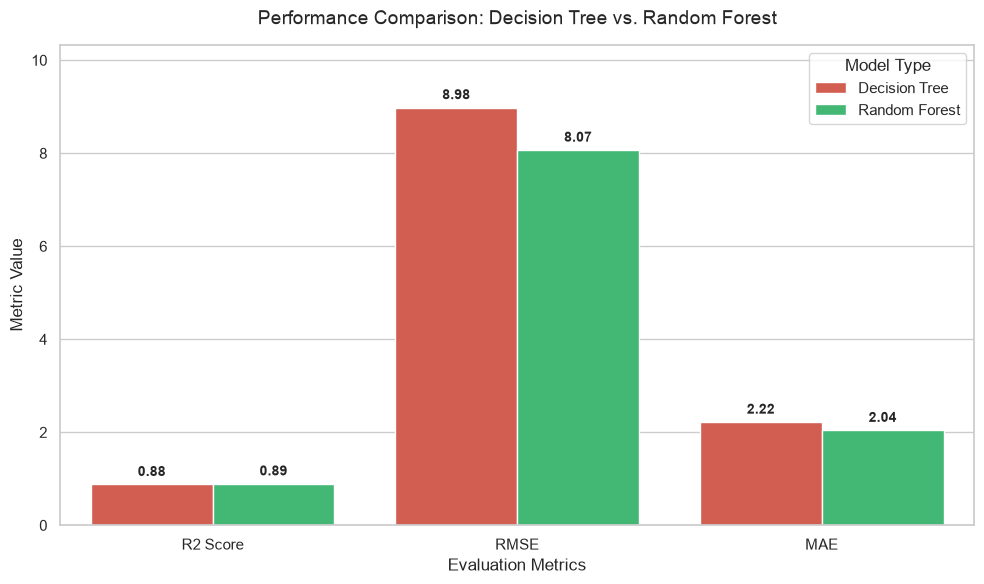

In [41]:
# Set plot style
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot grouped bar chart
ax = sns.barplot(
    data=metrics_df, 
    x='Metric', 
    y='Value', 
    hue='Model', 
    palette={'Decision Tree': '#e74c3c', 'Random Forest': '#2ecc71'}
)

# Add exact numbers above bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold',
                    xytext=(0, 4), textcoords='offset points')

plt.title('Performance Comparison: Decision Tree vs. Random Forest', fontsize=14, pad=15)
plt.ylabel('Metric Value', fontsize=12)
plt.xlabel('Evaluation Metrics', fontsize=12)
plt.ylim(0, max(metrics_df['Value']) * 1.15)
plt.legend(title='Model Type', loc='upper right')

plt.tight_layout()
plt.savefig('Performance Comparison: Decision Tree vs. Random Forest')
plt.show()

In [29]:
import pickle

pickle.dump(rf_pipeline, open('randomforest.pkl', 'wb'))


In [30]:
pickle.dump(dt_pipeline, open('decisiontree.pkl', 'wb'))